Import Libraries

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
from collections import defaultdict, deque
from tqdm import tqdm
import seaborn as sns

Combine all the datasets

In [2]:
print("preprocessing")

all_matches = pd.DataFrame()

for year in range (2000, 2025):
    current_file = "../data/atp_matches_" + str(year)+ ".csv"

    year_data = pd.read_csv(current_file)

    all_matches = pd.concat([all_matches, year_data], axis = 0)

print(all_matches.tail())

preprocessing
                            tourney_id                  tourney_name surface  \
3071  2024-M-DC-2024-WG2-PO-URU-MDA-01  Davis Cup WG2 PO: URU vs MDA    Clay   
3072  2024-M-DC-2024-WG2-PO-VIE-RSA-01  Davis Cup WG2 PO: VIE vs RSA    Hard   
3073  2024-M-DC-2024-WG2-PO-VIE-RSA-01  Davis Cup WG2 PO: VIE vs RSA    Hard   
3074  2024-M-DC-2024-WG2-PO-VIE-RSA-01  Davis Cup WG2 PO: VIE vs RSA    Hard   
3075  2024-M-DC-2024-WG2-PO-VIE-RSA-01  Davis Cup WG2 PO: VIE vs RSA    Hard   

      draw_size tourney_level  tourney_date  match_num  winner_id  \
3071          4             D      20240203          5     212051   
3072          4             D      20240202          1     122533   
3073          4             D      20240202          2     144748   
3074          4             D      20240202          4     122533   
3075          4             D      20240202          5     202475   

      winner_seed winner_entry                winner_name winner_hand  \
3071          NaN

Looking good but there's heaps of NaN values - empty values - so we will remove the rows with bad NaN values

In [3]:
print(all_matches.tail())
all_matches_filtered = all_matches.dropna(subset=[    
    "winner_id","loser_id","winner_ht","loser_ht","winner_age","loser_age",
    "w_ace","w_df","w_svpt","w_1stIn","w_1stWon","w_2ndWon","w_SvGms","w_bpSaved","w_bpFaced",
    "l_ace","l_df","l_svpt","l_1stIn","l_1stWon","l_2ndWon","l_SvGms","l_bpSaved","l_bpFaced",
    "winner_rank_points","loser_rank_points","winner_rank","loser_rank","surface"    
]) 

all_matches_filtered = all_matches_filtered.reset_index(drop=True)

print(all_matches_filtered.tail())


                            tourney_id                  tourney_name surface  \
3071  2024-M-DC-2024-WG2-PO-URU-MDA-01  Davis Cup WG2 PO: URU vs MDA    Clay   
3072  2024-M-DC-2024-WG2-PO-VIE-RSA-01  Davis Cup WG2 PO: VIE vs RSA    Hard   
3073  2024-M-DC-2024-WG2-PO-VIE-RSA-01  Davis Cup WG2 PO: VIE vs RSA    Hard   
3074  2024-M-DC-2024-WG2-PO-VIE-RSA-01  Davis Cup WG2 PO: VIE vs RSA    Hard   
3075  2024-M-DC-2024-WG2-PO-VIE-RSA-01  Davis Cup WG2 PO: VIE vs RSA    Hard   

      draw_size tourney_level  tourney_date  match_num  winner_id  \
3071          4             D      20240203          5     212051   
3072          4             D      20240202          1     122533   
3073          4             D      20240202          2     144748   
3074          4             D      20240202          4     122533   
3075          4             D      20240202          5     202475   

      winner_seed winner_entry                winner_name winner_hand  \
3071          NaN          NaN 

There's still heaps of data available to use even after removing these rows

We make a new dataframe with new features to be used for analysis

In [4]:
final_data = pd.DataFrame()
final_data["WINNER_ID"] = all_matches_filtered["winner_id"]
final_data["LOSER_ID"] = all_matches_filtered["loser_id"]
final_data["ATP_POINT_DIff"] = all_matches_filtered["winner_rank_points"] - all_matches_filtered["loser_rank_points"]
final_data["ATP_RANK_DIff"] = all_matches_filtered["winner_rank"] - all_matches_filtered["loser_rank"]
final_data["AGE_DIFF"] = all_matches_filtered["winner_age"] - all_matches_filtered["loser_age"]
final_data["HEIGHT_DIFF"] = all_matches_filtered["winner_ht"] - all_matches_filtered["loser_ht"]
final_data["BEST_OF"] = all_matches_filtered["best_of"]
final_data["DRAW_SIZE"] = all_matches_filtered["draw_size"]

In [5]:
matches_played = defaultdict(int)
matches_played_diff = []

for idx, (w_id, l_id) in enumerate(
    tqdm(zip(all_matches_filtered['winner_id'],
             all_matches_filtered['loser_id']),
             total = len(all_matches_filtered))):
    n_player_winner_matches = matches_played[w_id]
    n_player_loser_matches = matches_played[l_id]
    matches_played_diff.append(n_player_winner_matches-n_player_loser_matches)
    matches_played[w_id]+=1
    matches_played[l_id]+=1
final_data["DIFF_N_MATCHES"] = matches_played_diff

100%|██████████| 67424/67424 [00:00<00:00, 1286837.76it/s]


In [6]:
win_states = {}
for k in [3, 5, 10, 25, 50, 100]:
    last_k_matches = defaultdict(lambda: deque(maxlen=k))
    wins_last_k = []

    for w_id, l_id in tqdm(
        zip(all_matches_filtered['winner_id'],
            all_matches_filtered['loser_id']),
            total=len(all_matches_filtered)):
        
        # Check that it's a player's first ATP match
        if len(last_k_matches[w_id]) != 0:
            wins_count_w = sum(last_k_matches[w_id]) / len(last_k_matches[w_id])
        else:
            wins_count_w = 0

        if len(last_k_matches[l_id]) != 0:
            wins_count_l = sum(last_k_matches[l_id]) / len(last_k_matches[l_id])
        else:
            wins_count_l = 0
        
        # Update difference to dataset
        wins_last_k.append(wins_count_w-wins_count_l)

        # Update
        last_k_matches[w_id].append(1)
        last_k_matches[l_id].append(0)
        win_states[k] = last_k_matches

    name = "WIN_LAST_"+str(k)+"_DIFF"
    final_data[name] = wins_last_k

100%|██████████| 67424/67424 [00:00<00:00, 355568.91it/s]


In [7]:
# Calculate tour averages first, before the loop
tour_avg_ace = (all_matches_filtered['w_ace'].sum() + all_matches_filtered['l_ace'].sum()) / \
               (all_matches_filtered['w_svpt'].sum() + all_matches_filtered['l_svpt'].sum()) * 100

tour_avg_df = (all_matches_filtered['w_df'].sum() + all_matches_filtered['l_df'].sum()) / \
              (all_matches_filtered['w_svpt'].sum() + all_matches_filtered['l_svpt'].sum()) * 100

tour_avg_1stIn = (all_matches_filtered['w_1stIn'].sum() + all_matches_filtered['l_1stIn'].sum()) / \
                 (all_matches_filtered['w_svpt'].sum() + all_matches_filtered['l_svpt'].sum()) * 100

tour_avg_1stWon = (all_matches_filtered['w_1stWon'].sum() + all_matches_filtered['l_1stWon'].sum()) / \
                  (all_matches_filtered['w_1stIn'].sum() + all_matches_filtered['l_1stIn'].sum()) * 100

tour_avg_2ndWon = (all_matches_filtered['w_2ndWon'].sum() + all_matches_filtered['l_2ndWon'].sum()) / \
                  ((all_matches_filtered['w_svpt'] - all_matches_filtered['w_1stIn']).sum() + 
                   (all_matches_filtered['l_svpt'] - all_matches_filtered['l_1stIn']).sum()) * 100

tour_avg_bpSaved = (all_matches_filtered['w_bpSaved'].sum() + all_matches_filtered['l_bpSaved'].sum()) / \
                   (all_matches_filtered['w_bpFaced'].sum() + all_matches_filtered['l_bpFaced'].sum()) * 100

print(f"Tour averages:")
print(f"  Ace rate:       {tour_avg_ace:.2f}%")
print(f"  Double fault:   {tour_avg_df:.2f}%")
print(f"  1st serve in:   {tour_avg_1stIn:.2f}%")
print(f"  1st serve won:  {tour_avg_1stWon:.2f}%")
print(f"  2nd serve won:  {tour_avg_2ndWon:.2f}%")
print(f"  BP saved:       {tour_avg_bpSaved:.2f}%")

Tour averages:
  Ace rate:       7.60%
  Double fault:   3.75%
  1st serve in:   60.81%
  1st serve won:  71.23%
  2nd serve won:  50.61%
  BP saved:       60.45%


In [8]:
def mean(arr, default=0):
    if len(arr) == 0:
        return default
    else:
        total = 0
        for val in arr:
            total += val
        return total/(len(arr))

# Calculate the statistics in the last N matches
serve_states = {}
for k in [3, 5, 10, 20, 50, 100, 200, 300, 2000]:
    last_k_matches = defaultdict(lambda: defaultdict(lambda: deque(maxlen=k)))
    p_ace_k = []
    p_df_k = []
    p_1stIn_k = []
    p_1stWon_k = []
    p_2ndWon_k = []
    p_bpSaved_k = []

    for row in tqdm(all_matches_filtered.itertuples(index=False), total=len(all_matches_filtered)):
        # Extract features from row to readable variable names
        w_id, l_id = row.winner_id, row.loser_id
        w_ace, l_ace = row.w_ace, row.l_ace
        w_df, l_df = row.w_df, row.l_df
        w_svpt, l_svpt = row.w_svpt, row.l_svpt
        w_1stIn, l_1stIn = row.w_1stIn, row.l_1stIn
        w_1stWon, l_1stWon = row.w_1stWon, row.l_1stWon
        w_2ndWon, l_2ndWon = row.w_2ndWon, row.l_2ndWon
        w_SvGms, l_SvGms = row.w_SvGms, row.l_SvGms
        w_bpSaved, l_bpSaved = row.w_bpSaved, row.l_bpSaved
        w_bpFaced, l_bpFaced = row.w_bpFaced, row.l_bpFaced

        # Calculate averages and pass them to the dataset
        p_ace_k.append(mean(last_k_matches[w_id]["p_ace"], tour_avg_ace) - 
                    mean(last_k_matches[l_id]["p_ace"], tour_avg_ace))

        p_df_k.append(mean(last_k_matches[w_id]["p_df"], tour_avg_df) - 
                    mean(last_k_matches[l_id]["p_df"], tour_avg_df))

        p_1stIn_k.append(mean(last_k_matches[w_id]["p_1stIn"], tour_avg_1stIn) - 
                        mean(last_k_matches[l_id]["p_1stIn"], tour_avg_1stIn))

        p_1stWon_k.append(mean(last_k_matches[w_id]["p_1stWon"], tour_avg_1stWon) - 
                        mean(last_k_matches[l_id]["p_1stWon"], tour_avg_1stWon))

        p_2ndWon_k.append(mean(last_k_matches[w_id]["p_2ndWon"], tour_avg_2ndWon) - 
                        mean(last_k_matches[l_id]["p_2ndWon"], tour_avg_2ndWon))

        p_bpSaved_k.append(mean(last_k_matches[w_id]["p_bpSaved"], tour_avg_bpSaved) - 
                        mean(last_k_matches[l_id]["p_bpSaved"], tour_avg_bpSaved))


        # Update dictionaries
        if (w_svpt != 0) and (w_svpt != w_1stIn):
            # Percentatge of aces
            last_k_matches[w_id]["p_ace"].append(100*(w_ace/w_svpt))
            # Percentatge of double faults
            last_k_matches[w_id]["p_df"].append(100*(w_df/w_svpt))
            # Percentatge of first serve in
            last_k_matches[w_id]["p_1stIn"].append(100*(w_1stIn/w_svpt))
            # Percentatge of second serve won
            last_k_matches[w_id]["p_2ndWon"].append(100*(w_2ndWon/(w_svpt-w_1stIn)))
        if l_svpt != 0 and (l_svpt != l_1stIn):
            last_k_matches[l_id]["p_ace"].append(100*(l_ace/l_svpt))
            last_k_matches[l_id]["p_df"].append(100*(l_df/l_svpt))
            last_k_matches[l_id]["p_1stIn"].append(100*(l_1stIn/l_svpt))
            last_k_matches[l_id]["p_2ndWon"].append(100*(l_2ndWon/(l_svpt-l_1stIn)))

        # Percentatge of first serve won
        if w_1stIn != 0:
            last_k_matches[w_id]["p_1stWon"].append(100*(w_1stWon/w_1stIn))
        if l_1stIn != 0:
            last_k_matches[l_id]["p_1stWon"].append(100*(l_1stWon/l_1stIn))
        
        # Percentatge of break points won
        if w_bpFaced != 0:
            last_k_matches[w_id]["p_bpSaved"].append(100*(w_bpSaved/w_bpFaced))
        if l_bpFaced != 0:
            last_k_matches[l_id]["p_bpSaved"].append(100*(l_bpSaved/l_bpFaced))
        
    final_data["P_ACE_LAST_"+str(k)+"_DIFF"] = p_ace_k
    final_data["P_DF_LAST_"+str(k)+"_DIFF"] = p_df_k
    final_data["P_1ST_IN_LAST_"+str(k)+"_DIFF"] = p_1stIn_k
    final_data["P_1ST_WON_LAST_"+str(k)+"_DIFF"] = p_1stWon_k
    final_data["P_2ND_WON_LAST_"+str(k)+"_DIFF"] = p_2ndWon_k
    final_data["P_BP_SAVED_LAST_"+str(k)+"_DIFF"] = p_bpSaved_k
    serve_states[k] = last_k_matches


 15%|█▍        | 10016/67424 [00:00<00:00, 100155.80it/s]

100%|██████████| 67424/67424 [00:05<00:00, 13110.52it/s]


We create overall pre-match H2H between players and on specifics surfaces, then create new features being the difference in H2H

In [9]:
#Use defaultdict as when 2 players have never played before, the h2h is 0
#Dictionary is also good to use because we will be gradually adding entries
#Then we can get the H2H of players in O(1) time
h2h_surface_dict = defaultdict(lambda: defaultdict(int))
h2h_dict = defaultdict(int)
total_h2h_surface = []
total_h2h = []

for idx, (winner_id, loser_id, surface) in enumerate(
    tqdm(zip(all_matches_filtered['winner_id'], 
             all_matches_filtered['loser_id'], 
             all_matches_filtered['surface']), 
             total = len(all_matches_filtered))):

    wins = h2h_dict[(winner_id, loser_id)]
    loses = h2h_dict[(loser_id, winner_id)]
    wins_surface = h2h_surface_dict[surface][(winner_id, loser_id)]
    loses_surface = h2h_surface_dict[surface][(loser_id, winner_id)]

    total_h2h.append(wins-loses)
    total_h2h_surface.append(wins_surface-loses_surface)

    h2h_dict[(winner_id, loser_id)] += 1
    h2h_surface_dict[surface][(winner_id, loser_id)] += 1

final_data["H2H_DIFF"] = total_h2h
final_data["H2H_DIFF_SURFACE"] = total_h2h_surface

#Check to see if the H2H tally worked
print(final_data["H2H_DIFF"].unique())

100%|██████████| 67424/67424 [00:00<00:00, 565229.50it/s]


[  0  -1   1  -2   2   3  -3  -4   4   5  -6  -5   6   7   8  -9  -7   9
  10  11  12  13 -10 -14  -8  14  15  16 -11 -12 -13  17  18 -19 -16 -15
  19  20 -21]


In [10]:
neg21_idx = final_data[final_data["H2H_DIFF"] == -21].index

print(all_matches_filtered.loc[neg21_idx, ["winner_id", "winner_name", "loser_id", "loser_name", "surface"]])

       winner_id    winner_name  loser_id      loser_name surface
48440     104607  Tomas Berdych    104925  Novak Djokovic   Grass


Implment Tennis ELO

In [11]:
elo_players = defaultdict(int)
all_elo = defaultdict(lambda: deque())
df_elo_diff = []

for winner_id, loser_id in tqdm(zip(
    all_matches_filtered['winner_id'], 
    all_matches_filtered['loser_id']),
    total = len(all_matches_filtered)):

    #K-factor which affects how sensitive the ELO system is
    k = 32

    elo_winner = elo_players.get(winner_id, 1400)
    elo_loser = elo_players.get(loser_id, 1400)
    df_elo_diff.append(elo_winner-elo_loser)

    E_A = 1 / (1 + 10 ** ((elo_loser - elo_winner) / 400))
    E_B = 1 / (1 + 10 ** ((elo_winner - elo_loser) / 400))

    elo_winner += k * (1 - E_A)
    elo_loser += k * (0 - E_B)

    elo_players[winner_id] = elo_winner
    elo_players[loser_id] = elo_loser


    all_elo[winner_id].append(elo_winner)
    all_elo[loser_id].append(elo_loser)

final_data['ELO_DIFF'] = df_elo_diff

100%|██████████| 67424/67424 [00:00<00:00, 803103.27it/s]


Implement Elo per surface

In [12]:
elo_surfaces = defaultdict(lambda: defaultdict(int))
all_elo_surfaces = defaultdict(lambda: defaultdict(lambda: deque()))
df_elo_surfaces = []

for winner_id, loser_id, surface in tqdm(zip(
    all_matches_filtered['winner_id'], 
    all_matches_filtered['loser_id'],
    all_matches_filtered['surface']),
    total = len(all_matches_filtered)):

    k = 32

    # Get current ELO ratings (BEFORE this match)
    elo_winner = elo_surfaces[surface].get(winner_id, 1400)
    elo_loser = elo_surfaces[surface].get(loser_id, 1400)

    elo_diff = elo_winner - elo_loser
    df_elo_surfaces.append(elo_diff)


    E_A = 1 / (1 + 10 ** ((elo_loser - elo_winner) / 400))
    E_B = 1 / (1 + 10 ** ((elo_winner - elo_loser) / 400))

    elo_winner += k * (1 - E_A)
    elo_loser += k * (0 - E_B)

    elo_surfaces[surface][winner_id] = elo_winner
    elo_surfaces[surface][loser_id] = elo_loser

    all_elo_surfaces[surface][winner_id].append(elo_winner)
    all_elo_surfaces[surface][loser_id].append(elo_loser)

#append previous rankings on other surfaces so we can draw a continuous curve
    for s in ["Clay", "Grass", "Hard", "Carpet"]:
        if surface != s:
            all_elo_surfaces[s][winner_id].append(elo_surfaces[s].get(winner_id, 1400))
            all_elo_surfaces[s][loser_id].append(elo_surfaces[s].get(loser_id, 1400))
final_data["ELO_SURFACE_DIFF"] = df_elo_surfaces

100%|██████████| 67424/67424 [00:00<00:00, 374139.56it/s]


In [13]:
# Calculate the gradient difference on total ELO
elo_grad_states = {}
for n in [5, 10, 20, 35, 50, 100, 250]:
    elo_calc = defaultdict(lambda: deque(maxlen=n))
    grad_df_elo = []

    for w_id, l_id in tqdm(
        zip(all_matches_filtered['winner_id'],
            all_matches_filtered['loser_id']),
            total=len(all_matches_filtered)):
        k = 32

        # Get current of ELO (BEFORE the match)
        elo_w_list = elo_calc.get(w_id, deque([1400]))
        elo_l_list = elo_calc.get(l_id, deque([1400]))

        # Calculate gradient BEFORE match
        if len(elo_w_list) >= n and len(elo_l_list) >= n:
            slope_w = np.polyfit(np.arange(len(elo_w_list)), np.array(elo_w_list), 1)[0]
            slope_l = np.polyfit(np.arange(len(elo_l_list)), np.array(elo_l_list), 1)[0]
            grad_df_elo.append(slope_w-slope_l)
        else:
            grad_df_elo.append(0)

        # Calculate New Ratings
        elo_w = elo_w_list[-1]
        elo_l = elo_l_list[-1]

        exp_w = 1/(1+10**((elo_l-elo_w)/400))
        exp_l = 1/(1+10**((elo_w-elo_l)/400))

        elo_w += k*(1-exp_w)
        elo_l += k*(0-exp_l)

        # Store updated ratings
        elo_calc[w_id].append(elo_w)
        elo_calc[l_id].append(elo_l)
        elo_grad_states[n] = elo_calc

    final_data["ELO_GRAD_"+str(n)+"_DIFF"] = grad_df_elo


100%|██████████| 67424/67424 [00:00<00:00, 97082.23it/s] 


In [14]:
def plot_player_elo_graph(player_id, player_name):
    plt.close('all')

    player = list(all_elo[player_id])
    player_grass = list(all_elo_surfaces["Grass"][player_id])
    player_clay = list(all_elo_surfaces["Clay"][player_id])
    player_hard = list(all_elo_surfaces["Hard"][player_id])

    # Create a simple line plot
    fig = plt.figure(figsize=(8, 4))

    plt.plot(player_grass, marker='.', linewidth=0.5, markersize=1, linestyle='-', color='green', label="Grass")
    plt.plot(player_clay, marker='.', linewidth=0.5, markersize=1, linestyle='-', color='brown', label="Clay")
    plt.plot(player_hard, marker='.', linewidth=0.5, markersize=1, linestyle='-', color='#ADD8E6', label="Hard")
    plt.plot(player, marker='.', linewidth=0.5, markersize=1, linestyle='-', color='black', label="Overall")


    plt.title(player_name+"'s Elo Rating Over Time")
    plt.xlabel("Match Number")
    plt.ylabel("Elo Rating")

    plt.legend(loc="lower right")

    plt.grid(True)
    import os

    os.makedirs("./images", exist_ok=True)
    plt.savefig("./images/"+"".join(player_name.split())+"_elo_rating.png", dpi=500)

    plt.draw()
    plt.show()

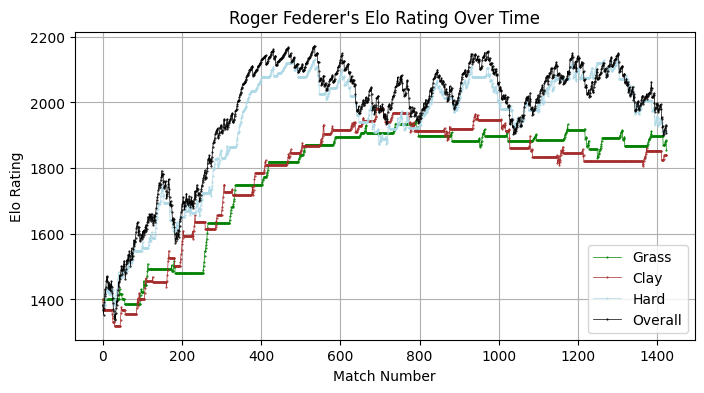

In [15]:
plot_player_elo_graph(103819, "Roger Federer")

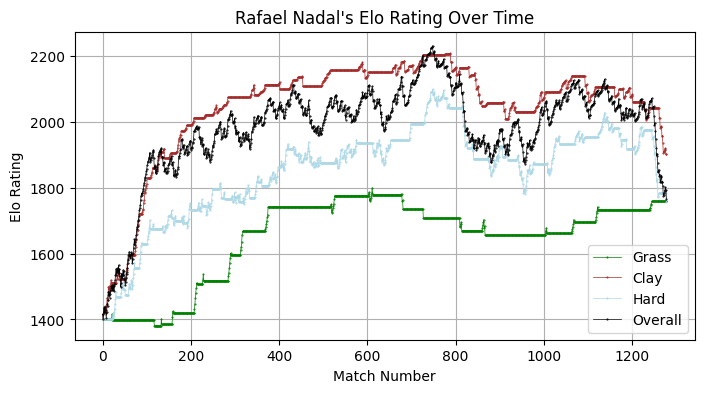

In [16]:
plot_player_elo_graph(104745, "Rafael Nadal")

Randomise Dataset

In [17]:
final_data["RESULT"] = 1
final_data

,WINNER_ID,LOSER_ID,ATP_POINT_DIff,ATP_RANK_DIff,AGE_DIFF,HEIGHT_DIFF,BEST_OF,DRAW_SIZE,DIFF_N_MATCHES,WIN_LAST_3_DIFF,WIN_LAST_5_DIFF,WIN_LAST_10_DIFF,WIN_LAST_25_DIFF,WIN_LAST_50_DIFF,WIN_LAST_100_DIFF,P_ACE_LAST_3_DIFF,P_DF_LAST_3_DIFF,P_1ST_IN_LAST_3_DIFF,P_1ST_WON_LAST_3_DIFF,P_2ND_WON_LAST_3_DIFF,P_BP_SAVED_LAST_3_DIFF,P_ACE_LAST_5_DIFF,P_DF_LAST_5_DIFF,P_1ST_IN_LAST_5_DIFF,P_1ST_WON_LAST_5_DIFF,P_2ND_WON_LAST_5_DIFF,P_BP_SAVED_LAST_5_DIFF,P_ACE_LAST_10_DIFF,P_DF_LAST_10_DIFF,P_1ST_IN_LAST_10_DIFF,P_1ST_WON_LAST_10_DIFF,P_2ND_WON_LAST_10_DIFF,P_BP_SAVED_LAST_10_DIFF,P_ACE_LAST_20_DIFF,P_DF_LAST_20_DIFF,P_1ST_IN_LAST_20_DIFF,P_1ST_WON_LAST_20_DIFF,P_2ND_WON_LAST_20_DIFF,P_BP_SAVED_LAST_20_DIFF,P_ACE_LAST_50_DIFF,P_DF_LAST_50_DIFF,P_1ST_IN_LAST_50_DIFF,P_1ST_WON_LAST_50_DIFF,P_2ND_WON_LAST_50_DIFF,P_BP_SAVED_LAST_50_DIFF,P_ACE_LAST_100_DIFF,P_DF_LAST_100_DIFF,P_1ST_IN_LAST_100_DIFF,P_1ST_WON_LAST_100_DIFF,P_2ND_WON_LAST_100_DIFF,P_BP_SAVED_LAST_100_DIFF,P_ACE_LAST_200_DIFF,P_DF_LAST_200_DIFF,P_1ST_IN_LAST_200_DIFF,P_1ST_WON_LAST_200_DIFF,P_2ND_WON_LAST_200_DIFF,P_BP_SAVED_LAST_200_DIFF,P_ACE_LAST_300_DIFF,P_DF_LAST_300_DIFF,P_1ST_IN_LAST_300_DIFF,P_1ST_WON_LAST_300_DIFF,P_2ND_WON_LAST_300_DIFF,P_BP_SAVED_LAST_300_DIFF,P_ACE_LAST_2000_DIFF,P_DF_LAST_2000_DIFF,P_1ST_IN_LAST_2000_DIFF,P_1ST_WON_LAST_2000_DIFF,P_2ND_WON_LAST_2000_DIFF,P_BP_SAVED_LAST_2000_DIFF,H2H_DIFF,H2H_DIFF_SURFACE,ELO_DIFF,ELO_SURFACE_DIFF,ELO_GRAD_5_DIFF,ELO_GRAD_10_DIFF,ELO_GRAD_20_DIFF,ELO_GRAD_35_DIFF,ELO_GRAD_50_DIFF,ELO_GRAD_100_DIFF,ELO_GRAD_250_DIFF,RESULT
0,103163,101543,1017.0,-52.0,-9.4,8.0,3,32,0,0.000000,0.0,0.0,0.00,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,102607,102644,-566.0,162.0,0.2,7.0,3,32,0,0.000000,0.0,0.0,0.00,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,103252,102238,77.0,-11.0,-5.2,2.0,3,32,0,0.000000,0.0,0.0,0.00,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,103507,103819,152.0,-16.0,1.5,-2.0,3,32,0,0.000000,0.0,0.0,0.00,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.0,0.0,

In [18]:
columns_to_randomize = []

for val in list(final_data.columns):
    if "DIFF" in val:
        print(val)
        columns_to_randomize.append(val)
columns_to_randomize.append("RESULT")
columns_to_randomize.append("WINNER_ID")
columns_to_randomize.append("LOSER_ID")
final_data[columns_to_randomize] = final_data[columns_to_randomize].apply(
    lambda row: row * (-1) if np.random.rand() < 0.5 else row, axis = 1)

AGE_DIFF
HEIGHT_DIFF
DIFF_N_MATCHES
WIN_LAST_3_DIFF
WIN_LAST_5_DIFF
WIN_LAST_10_DIFF
WIN_LAST_25_DIFF
WIN_LAST_50_DIFF
WIN_LAST_100_DIFF
P_ACE_LAST_3_DIFF
P_DF_LAST_3_DIFF
P_1ST_IN_LAST_3_DIFF
P_1ST_WON_LAST_3_DIFF
P_2ND_WON_LAST_3_DIFF
P_BP_SAVED_LAST_3_DIFF
P_ACE_LAST_5_DIFF
P_DF_LAST_5_DIFF
P_1ST_IN_LAST_5_DIFF
P_1ST_WON_LAST_5_DIFF
P_2ND_WON_LAST_5_DIFF
P_BP_SAVED_LAST_5_DIFF
P_ACE_LAST_10_DIFF
P_DF_LAST_10_DIFF
P_1ST_IN_LAST_10_DIFF
P_1ST_WON_LAST_10_DIFF
P_2ND_WON_LAST_10_DIFF
P_BP_SAVED_LAST_10_DIFF
P_ACE_LAST_20_DIFF
P_DF_LAST_20_DIFF
P_1ST_IN_LAST_20_DIFF
P_1ST_WON_LAST_20_DIFF
P_2ND_WON_LAST_20_DIFF
P_BP_SAVED_LAST_20_DIFF
P_ACE_LAST_50_DIFF
P_DF_LAST_50_DIFF
P_1ST_IN_LAST_50_DIFF
P_1ST_WON_LAST_50_DIFF
P_2ND_WON_LAST_50_DIFF
P_BP_SAVED_LAST_50_DIFF
P_ACE_LAST_100_DIFF
P_DF_LAST_100_DIFF
P_1ST_IN_LAST_100_DIFF
P_1ST_WON_LAST_100_DIFF
P_2ND_WON_LAST_100_DIFF
P_BP_SAVED_LAST_100_DIFF
P_ACE_LAST_200_DIFF
P_DF_LAST_200_DIFF
P_1ST_IN_LAST_200_DIFF
P_1ST_WON_LAST_200_DIFF
P_2ND_WON

In [19]:
def fix_ids(row):
    winner, loser = row['WINNER_ID'], row['LOSER_ID']
    if winner < 0 and loser < 0:
        winner, loser = abs(loser), abs(winner)
    return pd.Series([winner, loser])

final_data[['WINNER_ID', 'LOSER_ID']] = final_data.apply(fix_ids, axis=1)
final_data.rename(columns = {'WINNER_ID': 'PLAYER_1', 'LOSER_ID': 'PLAYER_2'}, inplace = True)
final_data

,PLAYER_1,PLAYER_2,ATP_POINT_DIff,ATP_RANK_DIff,AGE_DIFF,HEIGHT_DIFF,BEST_OF,DRAW_SIZE,DIFF_N_MATCHES,WIN_LAST_3_DIFF,WIN_LAST_5_DIFF,WIN_LAST_10_DIFF,WIN_LAST_25_DIFF,WIN_LAST_50_DIFF,WIN_LAST_100_DIFF,P_ACE_LAST_3_DIFF,P_DF_LAST_3_DIFF,P_1ST_IN_LAST_3_DIFF,P_1ST_WON_LAST_3_DIFF,P_2ND_WON_LAST_3_DIFF,P_BP_SAVED_LAST_3_DIFF,P_ACE_LAST_5_DIFF,P_DF_LAST_5_DIFF,P_1ST_IN_LAST_5_DIFF,P_1ST_WON_LAST_5_DIFF,P_2ND_WON_LAST_5_DIFF,P_BP_SAVED_LAST_5_DIFF,P_ACE_LAST_10_DIFF,P_DF_LAST_10_DIFF,P_1ST_IN_LAST_10_DIFF,P_1ST_WON_LAST_10_DIFF,P_2ND_WON_LAST_10_DIFF,P_BP_SAVED_LAST_10_DIFF,P_ACE_LAST_20_DIFF,P_DF_LAST_20_DIFF,P_1ST_IN_LAST_20_DIFF,P_1ST_WON_LAST_20_DIFF,P_2ND_WON_LAST_20_DIFF,P_BP_SAVED_LAST_20_DIFF,P_ACE_LAST_50_DIFF,P_DF_LAST_50_DIFF,P_1ST_IN_LAST_50_DIFF,P_1ST_WON_LAST_50_DIFF,P_2ND_WON_LAST_50_DIFF,P_BP_SAVED_LAST_50_DIFF,P_ACE_LAST_100_DIFF,P_DF_LAST_100_DIFF,P_1ST_IN_LAST_100_DIFF,P_1ST_WON_LAST_100_DIFF,P_2ND_WON_LAST_100_DIFF,P_BP_SAVED_LAST_100_DIFF,P_ACE_LAST_200_DIFF,P_DF_LAST_200_DIFF,P_1ST_IN_LAST_200_DIFF,P_1ST_WON_LAST_200_DIFF,P_2ND_WON_LAST_200_DIFF,P_BP_SAVED_LAST_200_DIFF,P_ACE_LAST_300_DIFF,P_DF_LAST_300_DIFF,P_1ST_IN_LAST_300_DIFF,P_1ST_WON_LAST_300_DIFF,P_2ND_WON_LAST_300_DIFF,P_BP_SAVED_LAST_300_DIFF,P_ACE_LAST_2000_DIFF,P_DF_LAST_2000_DIFF,P_1ST_IN_LAST_2000_DIFF,P_1ST_WON_LAST_2000_DIFF,P_2ND_WON_LAST_2000_DIFF,P_BP_SAVED_LAST_2000_DIFF,H2H_DIFF,H2H_DIFF_SURFACE,ELO_DIFF,ELO_SURFACE_DIFF,ELO_GRAD_5_DIFF,ELO_GRAD_10_DIFF,ELO_GRAD_20_DIFF,ELO_GRAD_35_DIFF,ELO_GRAD_50_DIFF,ELO_GRAD_100_DIFF,ELO_GRAD_250_DIFF,RESULT
0,103163.0,101543.0,1017.0,-52.0,-9.4,8.0,3,32,0.0,0.000000,0.0,0.0,0.00,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,102644.0,102607.0,-566.0,162.0,-0.2,-7.0,3,32,-0.0,-0.000000,-0.0,-0.0,-0.00,-0.00,-0.00,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.0,-0.0,-0.000000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-1.0
2,102238.0,103252.0,77.0,-11.0,5.2,-2.0,3,32,-0.0,-0.000000,-0.0,-0.0,-0.00,-0.00,-0.00,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.0,-0.0,-0.000000,-0.000000,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-1.0
3,103819.0,103507.0,152.0,-16.0,-1.5,2.0,3,32,-0.0,-0.000000,-0.0,-0.0,-0.00,-0.00,-0.00,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.0

Plot the Data

Text(0.5, 1.02, 'Pairplot of Key Features')

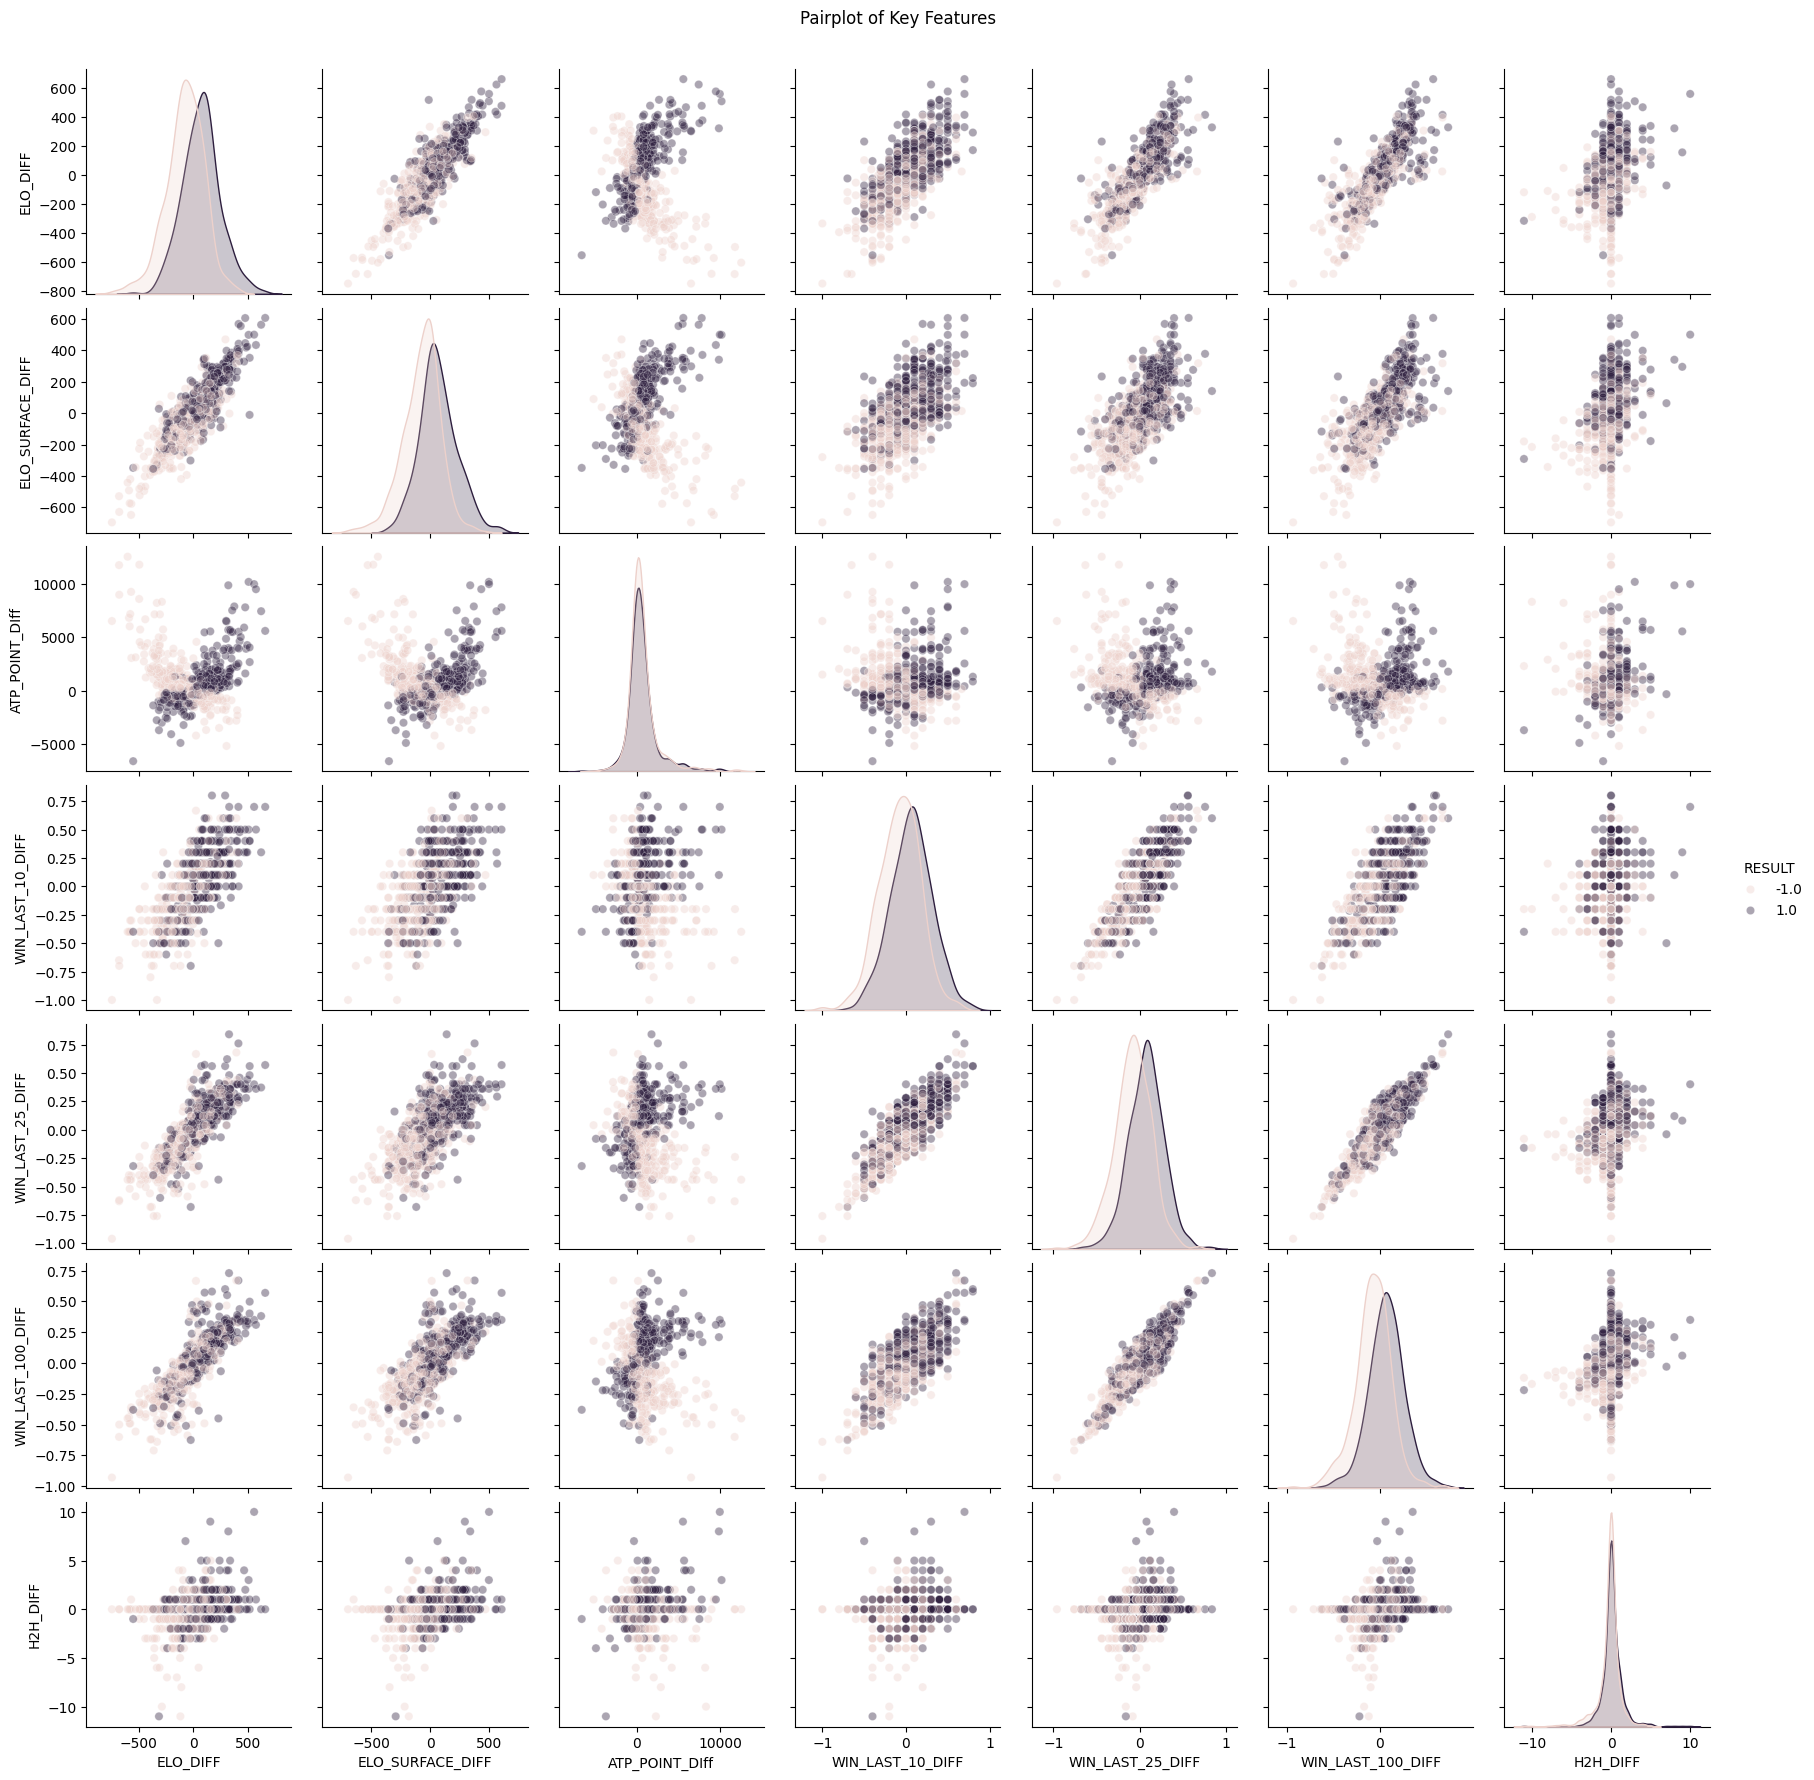

In [20]:
key_features = [
    'ELO_DIFF', 'ELO_SURFACE_DIFF', 'ATP_POINT_DIff',
    'WIN_LAST_10_DIFF', 'WIN_LAST_25_DIFF', 'WIN_LAST_100_DIFF',
    'H2H_DIFF', 'RESULT'
]

sns.pairplot(final_data[key_features].sample(1000), hue='RESULT', plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot of Key Features', y=1.02)



Text(0.5, 1.0, 'Top 15 Feature Importances')

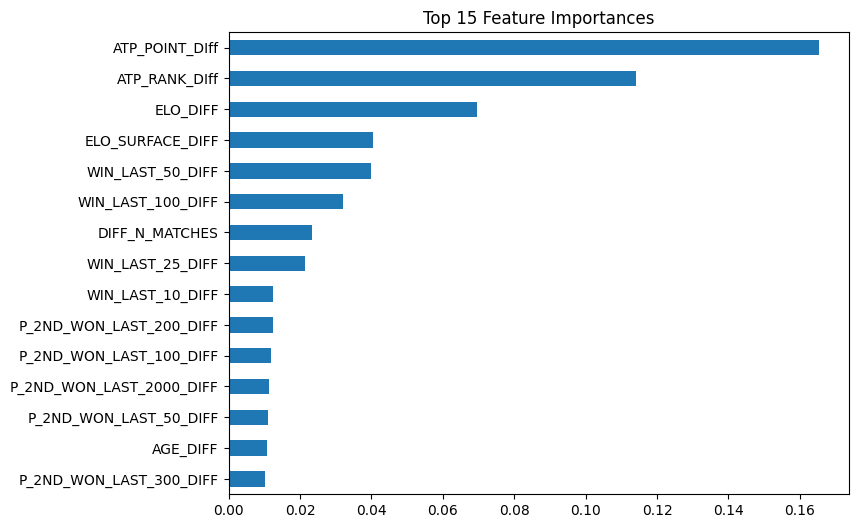

In [21]:
#sns.pairplot(final_data, hue = 'RESULT')
from sklearn.ensemble import RandomForestClassifier

X = final_data.drop(columns=['PLAYER_1','PLAYER_2','RESULT'])
y = final_data['RESULT']
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(15).sort_values().plot.barh(figsize=(8,6))
plt.title('Top 15 Feature Importances')


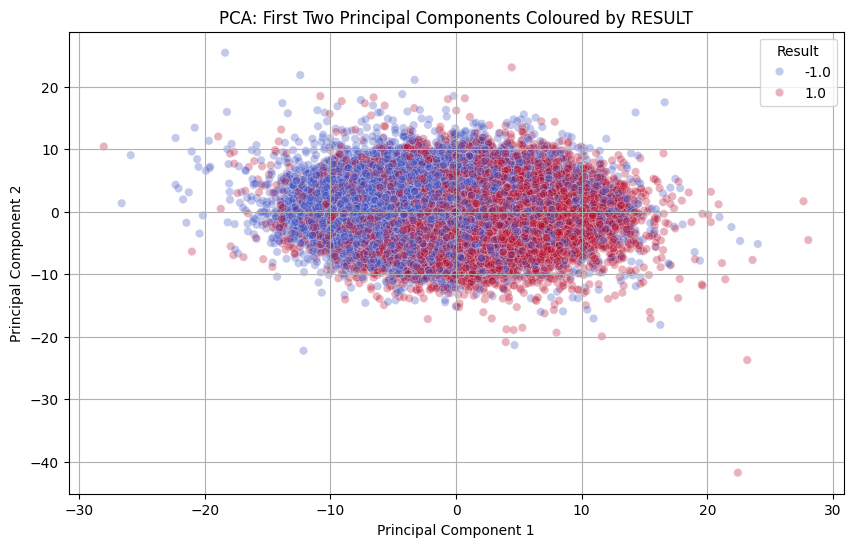

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = final_data.drop(columns=['PLAYER_1','PLAYER_2','RESULT'])
y = final_data['RESULT']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=30)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({'PC1': X_pca[:,0], 'PC2': X_pca[:,1], 'RESULT': y.values})

plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'], hue=pca_df['RESULT'], palette='coolwarm', alpha=0.3)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: First Two Principal Components Coloured by RESULT')
plt.legend(title='Result')
plt.grid(True)
plt.show()



Feature importance in PC1-PC4:
                               PC1       PC2       PC3       PC4
P_1ST_WON_LAST_100_DIFF   0.195998  0.078096  0.008253  0.047546
P_1ST_WON_LAST_50_DIFF    0.195524  0.076621  0.009606  0.038008
P_1ST_WON_LAST_200_DIFF   0.194711  0.079608  0.006374  0.052183
P_1ST_WON_LAST_300_DIFF   0.193743  0.080362  0.005144  0.053841
P_1ST_WON_LAST_2000_DIFF  0.191979  0.084808  0.002086  0.057951
...                            ...       ...       ...       ...
P_1ST_IN_LAST_10_DIFF     0.002408  0.177198  0.261588  0.037131
ATP_RANK_DIff             0.001322  0.000243  0.003217  0.003726
DRAW_SIZE                 0.001072  0.000097  0.003556  0.006422
BEST_OF                   0.000694  0.000193  0.001875  0.005178
ATP_POINT_DIff            0.000535  0.000501  0.000803  0.004002

[78 rows x 4 columns]


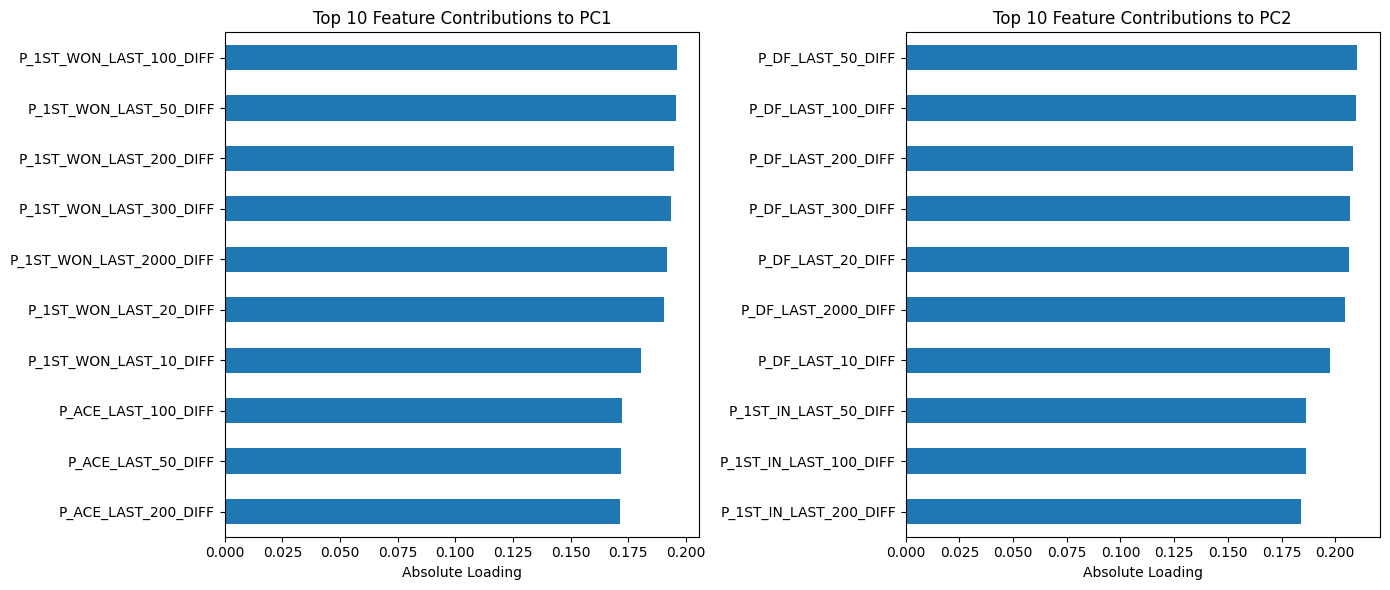

In [23]:
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(30)],
                        index=X.columns)

print("Feature importance in PC1-PC4:")
print(loadings[['PC1', 'PC2', 'PC3', 'PC4']].abs().sort_values(by='PC1', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, pc in zip(axes, ['PC1', 'PC2']):
    loadings[pc].abs().sort_values(ascending=True).tail(10).plot.barh(ax=ax)
    ax.set_title(f'Top 10 Feature Contributions to {pc}')
    ax.set_xlabel('Absolute Loading')
plt.tight_layout()
plt.show()


Adjusted Rand Index: 0.050


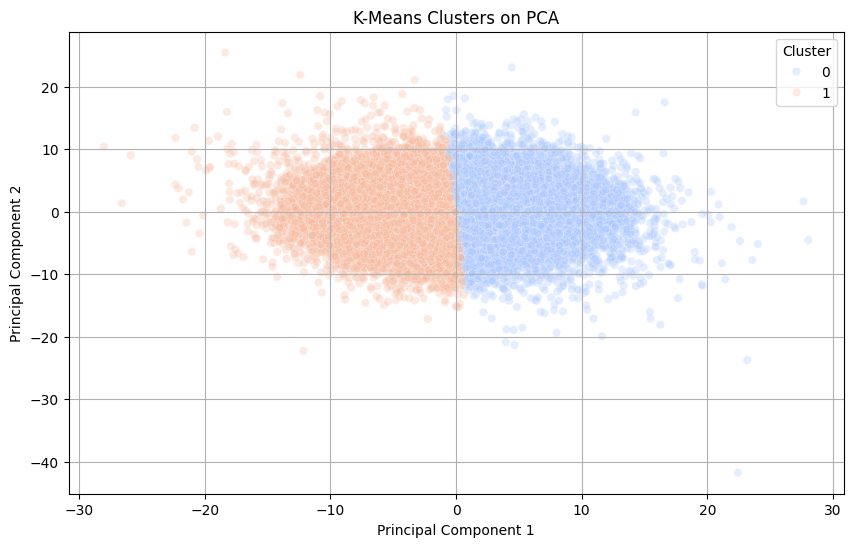

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

km = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = km.fit_predict(X_pca)

ari = adjusted_rand_score(y, clusters)
print(f'Adjusted Rand Index: {ari:.3f}')

pca_df['Cluster'] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'], hue=pca_df['Cluster'], palette='coolwarm', alpha=0.3)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters on PCA')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


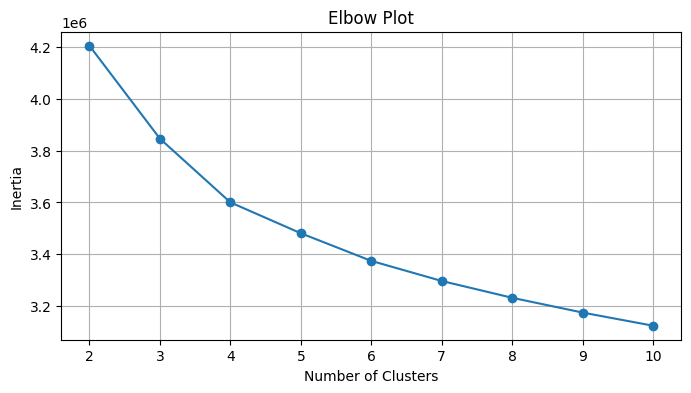

In [25]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Plot')
plt.grid(True)
plt.show()


/Users/george/Desktop/Project 1 Tennis/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


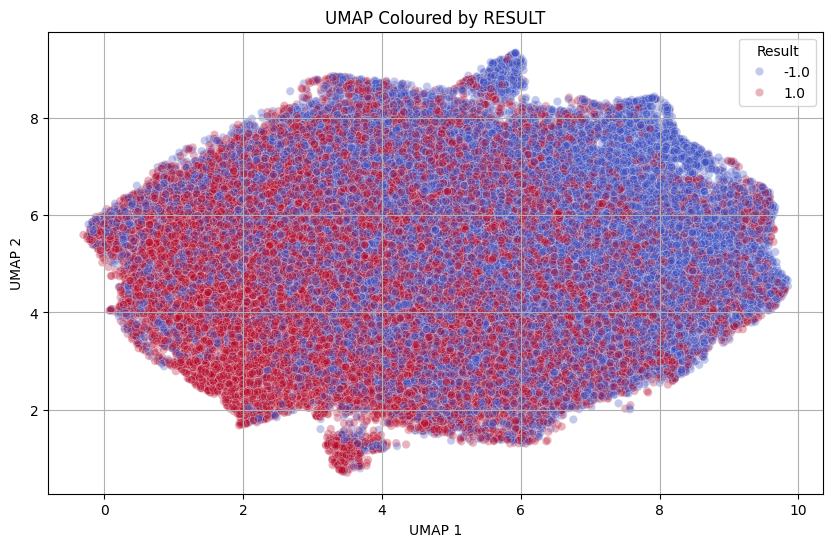

In [26]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_pca)

umap_df = pd.DataFrame({'UMAP1': X_umap[:,0], 'UMAP2': X_umap[:,1], 'RESULT': y.values})

plt.figure(figsize=(10, 6))
sns.scatterplot(x=umap_df['UMAP1'], y=umap_df['UMAP2'], hue=umap_df['RESULT'], palette='coolwarm', alpha=0.3)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Coloured by RESULT')
plt.legend(title='Result')
plt.grid(True)
plt.show()


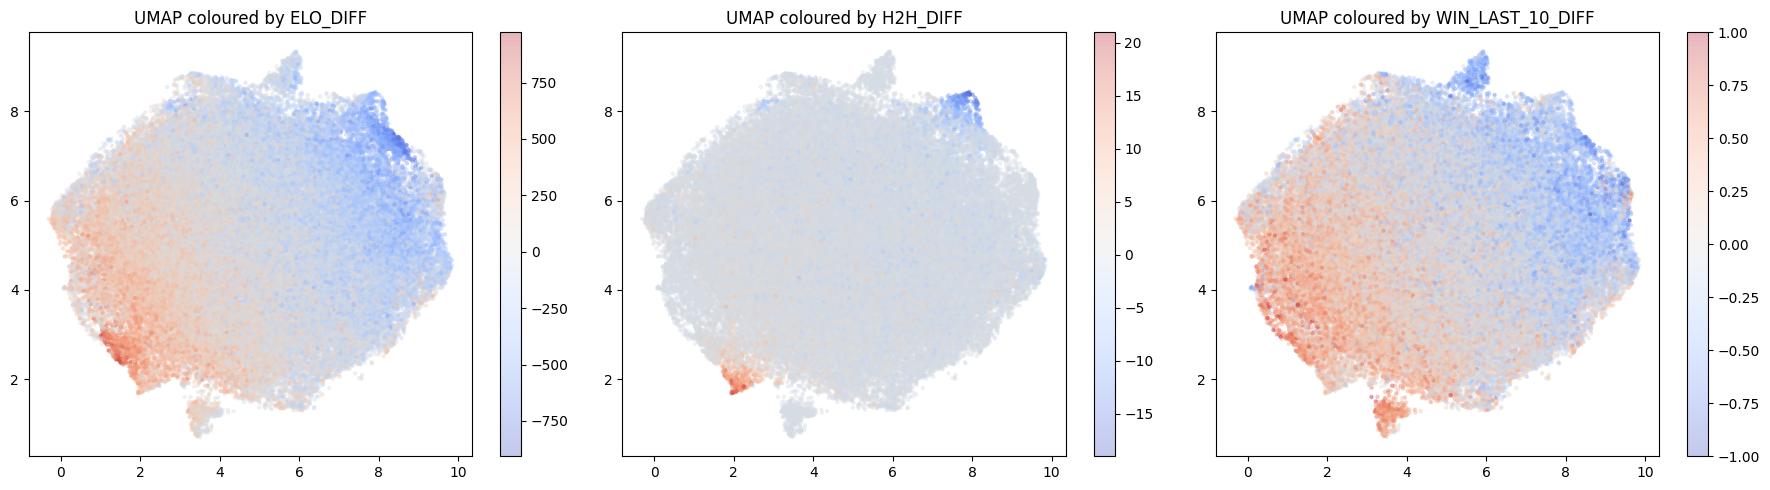

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feature in zip(axes, ['ELO_DIFF', 'H2H_DIFF', 'WIN_LAST_10_DIFF']):
    sc = ax.scatter(X_umap[:,0], X_umap[:,1], c=final_data[feature], cmap='coolwarm', alpha=0.3, s=5)
    plt.colorbar(sc, ax=ax)
    ax.set_title(f'UMAP coloured by {feature}')
plt.tight_layout()
plt.show()


In [28]:
aos = pd.read_csv("../data/aus_open_2025_new.csv")
surface = "Hard"  # AO is always hard court since 1988

test_data = pd.DataFrame()
test_data["PLAYER_1"] = aos["p1_id"]
test_data["PLAYER_2"] = aos["p2_id"]
test_data["RESULT"]   = aos["RESULT"]  # 1 = p1 won

# Static features
test_data["ATP_POINT_DIff"] = aos["p1_rank_points"] - aos["p2_rank_points"]
test_data["ATP_RANK_DIff"]  = aos["p1_rank"]        - aos["p2_rank"]
test_data["AGE_DIFF"]       = aos["p1_age"]         - aos["p2_age"]
test_data["HEIGHT_DIFF"]    = aos["p1_ht"]          - aos["p2_ht"]
test_data["BEST_OF"]        = aos["best_of"]
test_data["DRAW_SIZE"]      = aos["draw_size"]

# Matches played
test_data["DIFF_N_MATCHES"] = [
    matches_played[p1] - matches_played[p2]
    for p1, p2 in zip(aos["p1_id"], aos["p2_id"])
]

# Win rate last k
for k in [3, 5, 10, 25, 50, 100]:
    state = win_states[k]
    diffs = []
    for p1, p2 in zip(aos["p1_id"], aos["p2_id"]):
        h1, h2 = state[p1], state[p2]
        r1 = sum(h1) / len(h1) if len(h1) > 0 else 0
        r2 = sum(h2) / len(h2) if len(h2) > 0 else 0
        diffs.append(r1 - r2)
    test_data[f"WIN_LAST_{k}_DIFF"] = diffs

# Serve stats last k
for k in [3, 5, 10, 20, 50, 100, 200, 300, 2000]:
    state = serve_states[k]
    ace_d, df_d, fin_d, fwon_d, swon_d, bp_d = [], [], [], [], [], []
    for p1, p2 in zip(aos["p1_id"], aos["p2_id"]):
        for stat, default, lst in [
            ("p_ace",    tour_avg_ace,    ace_d),
            ("p_df",     tour_avg_df,     df_d),
            ("p_1stIn",  tour_avg_1stIn,  fin_d),
            ("p_1stWon", tour_avg_1stWon, fwon_d),
            ("p_2ndWon", tour_avg_2ndWon, swon_d),
            ("p_bpSaved",tour_avg_bpSaved,bp_d),
        ]:
            lst.append(mean(state[p1][stat], default) - mean(state[p2][stat], default))
    test_data[f"P_ACE_LAST_{k}_DIFF"]      = ace_d
    test_data[f"P_DF_LAST_{k}_DIFF"]       = df_d
    test_data[f"P_1ST_IN_LAST_{k}_DIFF"]   = fin_d
    test_data[f"P_1ST_WON_LAST_{k}_DIFF"]  = fwon_d
    test_data[f"P_2ND_WON_LAST_{k}_DIFF"]  = swon_d
    test_data[f"P_BP_SAVED_LAST_{k}_DIFF"] = bp_d

# H2H
test_data["H2H_DIFF"] = [
    h2h_dict[(p1, p2)] - h2h_dict[(p2, p1)]
    for p1, p2 in zip(aos["p1_id"], aos["p2_id"])
]
test_data["H2H_DIFF_SURFACE"] = [
    h2h_surface_dict[surface][(p1, p2)] - h2h_surface_dict[surface][(p2, p1)]
    for p1, p2 in zip(aos["p1_id"], aos["p2_id"])
]

# ELO
test_data["ELO_DIFF"] = [
    elo_players.get(p1, 1400) - elo_players.get(p2, 1400)
    for p1, p2 in zip(aos["p1_id"], aos["p2_id"])
]
test_data["ELO_SURFACE_DIFF"] = [
    elo_surfaces[surface].get(p1, 1400) - elo_surfaces[surface].get(p2, 1400)
    for p1, p2 in zip(aos["p1_id"], aos["p2_id"])
]

# ELO gradient
for n in [5, 10, 20, 35, 50, 100, 250]:
    state = elo_grad_states[n]
    diffs = []
    for p1, p2 in zip(aos["p1_id"], aos["p2_id"]):
        l1 = list(state.get(p1, deque([1400])))
        l2 = list(state.get(p2, deque([1400])))
        if len(l1) >= n and len(l2) >= n:
            s1 = np.polyfit(np.arange(len(l1)), np.array(l1), 1)[0]
            s2 = np.polyfit(np.arange(len(l2)), np.array(l2), 1)[0]
            diffs.append(s1 - s2)
        else:
            diffs.append(0)
    test_data[f"ELO_GRAD_{n}_DIFF"] = diffs

test_data


,PLAYER_1,PLAYER_2,RESULT,ATP_POINT_DIff,ATP_RANK_DIff,AGE_DIFF,HEIGHT_DIFF,BEST_OF,DRAW_SIZE,DIFF_N_MATCHES,WIN_LAST_3_DIFF,WIN_LAST_5_DIFF,WIN_LAST_10_DIFF,WIN_LAST_25_DIFF,WIN_LAST_50_DIFF,WIN_LAST_100_DIFF,P_ACE_LAST_3_DIFF,P_DF_LAST_3_DIFF,P_1ST_IN_LAST_3_DIFF,P_1ST_WON_LAST_3_DIFF,P_2ND_WON_LAST_3_DIFF,P_BP_SAVED_LAST_3_DIFF,P_ACE_LAST_5_DIFF,P_DF_LAST_5_DIFF,P_1ST_IN_LAST_5_DIFF,P_1ST_WON_LAST_5_DIFF,P_2ND_WON_LAST_5_DIFF,P_BP_SAVED_LAST_5_DIFF,P_ACE_LAST_10_DIFF,P_DF_LAST_10_DIFF,P_1ST_IN_LAST_10_DIFF,P_1ST_WON_LAST_10_DIFF,P_2ND_WON_LAST_10_DIFF,P_BP_SAVED_LAST_10_DIFF,P_ACE_LAST_20_DIFF,P_DF_LAST_20_DIFF,P_1ST_IN_LAST_20_DIFF,P_1ST_WON_LAST_20_DIFF,P_2ND_WON_LAST_20_DIFF,P_BP_SAVED_LAST_20_DIFF,P_ACE_LAST_50_DIFF,P_DF_LAST_50_DIFF,P_1ST_IN_LAST_50_DIFF,P_1ST_WON_LAST_50_DIFF,P_2ND_WON_LAST_50_DIFF,P_BP_SAVED_LAST_50_DIFF,P_ACE_LAST_100_DIFF,P_DF_LAST_100_DIFF,P_1ST_IN_LAST_100_DIFF,P_1ST_WON_LAST_100_DIFF,P_2ND_WON_LAST_100_DIFF,P_BP_SAVED_LAST_100_DIFF,P_ACE_LAST_200_DIFF,P_DF_LAST_200_DIFF,P_1ST_IN_LAST_200_DIFF,P_1ST_WON_LAST_200_DIFF,P_2ND_WON_LAST_200_DIFF,P_BP_SAVED_LAST_200_DIFF,P_ACE_LAST_300_DIFF,P_DF_LAST_300_DIFF,P_1ST_IN_LAST_300_DIFF,P_1ST_WON_LAST_300_DIFF,P_2ND_WON_LAST_300_DIFF,P_BP_SAVED_LAST_300_DIFF,P_ACE_LAST_2000_DIFF,P_DF_LAST_2000_DIFF,P_1ST_IN_LAST_2000_DIFF,P_1ST_WON_LAST_2000_DIFF,P_2ND_WON_LAST_2000_DIFF,P_BP_SAVED_LAST_2000_DIFF,H2H_DIFF,H2H_DIFF_SURFACE,ELO_DIFF,ELO_SURFACE_DIFF,ELO_GRAD_5_DIFF,ELO_GRAD_10_DIFF,ELO_GRAD_20_DIFF,ELO_GRAD_35_DIFF,ELO_GRAD_50_DIFF,ELO_GRAD_100_DIFF,ELO_GRAD_250_DIFF
0,117357,200384,0,-380,98,3.358658,10.0,5,128,-91,-0.666667,-0.6,-0.200000,-0.280000,-0.180000,-0.216667,-2.340095,1.467278,7.286214,-9.921019,1.555602,15.158730,-1.640182,1.701086,5.990463,-7.482893,-0.295420,9.095238,-1.528587,0.440587,8.735535,-3.432360,0.970871,1.630952,-1.240673,0.661685,10.460870,-3.467935,-3.540673,3.179113,-1.053654,0.015472,9.627958,-2.318236,-0.457323,-0.265795,-0.797808,0.039302,10.052860,-2.571529,-0.447585,-3.265772,-0.797808,0.039302,10.052860,-2.571529,-0.447585,-3.265772,-0.797808,0.039302,10.052860,-2.571529,-0.447585,-3.265772,-0.797808,0.039302,10.052860,-2.571529,-0.447585,-3.265772,0,0,-83.708777,1.431888,-3.234248,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,202261,209950,0,-1653,72,2.975359,8.0,5,128,-83,0.000000,0.2,-0.100000,-0.143333,-0.163333,-0.153333,1.021036,1.331668,0.338129,-9.683379,-1.046296,16.964887,-0.520253,1.056297,-1.963636,-7.118637,3.161600,4.118326,0.631569,0.720940,-1.094755,-5.797970,4.781281,-3.148629,0.645039,1.602176,-2.317081,-7.531428,-1.603477,-0.616973,3.469000,1.327778,-2.145912,-3.010476,-1.854002,4.239501,3.288351,1.002959,-2.145184,-2.270773,-2.006121,3.210429,3.179743,0.986300,-2.203070,-2.254653,-2.269684,3.082787,3.179743,0.986300,-2.203070,-2.254653,-2.269684,3.082787,3.179743,0.986300,-2.203070,-2.254653,-2.269684,3.082787,0,0,-206.618045,-160.556617,4.158553,5.377608,1.906771,0.000000,0.000000,0.000000,0.000000
2,105453,106329,1,177,-29,4.419576,-5.0,5,128,422,-0.333333,0.0,0.200000,-0.080000,0.140000,0.120000,-8.859508,-2.031115,2.699578,1.816997,-8.613072,-4.960317,-5.569444,-0.232038,1.316402,-0.894885,-7.331791,-15.119048,-5.158910,-0.706292,-0.672146,-1.143027,-4.778059,-13.253968,-5.310488,-1.129117,2.656138,-6.964032,-4.318517,-17.011905,-4.722848,-0.822750,2.903476,-7.277411,0.920291,-1.654118,-5.084294,0.179380,-0.568814,-5.714163,-0.677971,-6.984240,-3.340580,-0.002326,-2.345252,-2.675414,2.291392,-1.337462,-2.927493,0.049166,-3.003645,-1.284646,2.134243,-0.262085,-2.578874,0.605608,-3.689601,-1.002906,1.227574,-0.601414,1,0,131.793024,234.990203,0.522665,9.370577,0.883913,-5.619719,-4.284280,-2.487840,0.000000
3,134770,144719,1,3288,-56,-1.632444,0.0,5,128,159,0.666667,0.4,0.300000,0.160000,0.260000,0.230000,7.608016,-4.254308,2.699290,18.460926,6.606241,-13.518519,3.980888,-4.008770,4.264613,11.702241,3.727643,-11.448773,4.478360,-2.570188,5.286318,10.952576,6.696397,-2.740727,3.207042,-1.885084,

In [43]:
aos

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,p1_id,p1_seed,p1_entry,p1_name,p1_hand,p1_ht,p1_ioc,p1_age,p2_id,p2_seed,p2_entry,p2_name,p2_hand,p2_ht,p2_ioc,p2_age,score,best_of,round,minutes,p1_ace,p1_df,p1_svpt,p1_1stIn,p1_1stWon,p1_2ndWon,p1_SvGms,p1_bpSaved,p1_bpFaced,p2_ace,p2_df,p2_svpt,p2_1stIn,p2_1stWon,p2_2ndWon,p2_SvGms,p2_bpSaved,p2_bpFaced,p1_rank,p1_rank_points,p2_rank,p2_rank_points,RESULT
0,AUSTRALIAN_OPEN_2025,0.0,Hard,128,0.0,0.0,0.0,117357,0.0,0.0,0.0,0.0,183.0,0.0,27.873374,200384,0.0,0.0,0.0,0.0,173.0,0.0,24.514716,0.0,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,179,323,81,703,0
1,AUSTRALIAN_OPEN_2025,0.0,Hard,128,0.0,0.0,0.0,202261,0.0,0.0,0.0,0.0,193.0,0.0,23.780287,209950,0.0,0.0,0.0,0.0,185.0,0.0,20.804928,0.0,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,93,627,21,2280,0
2,AUSTRALIAN_OPEN_2025,0.0,Hard,128,0.0,0.0,0.0,105453,0.0,0.0,0.0,0.0,178.0,0.0,35.257358,106329,0.0,0.0,0.0,0.0,183.0,0.0,30.837782,0.0,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,76,743,105,566,1
3,AUSTRALIAN_OPEN_2025,0.0,Hard,128,0.0,0.0,0.0,134770,0.0,0.0,0.0,0.0,183.0,0.0,26.276523,144719,0.0,0.0,0.0,0.0,183.0,0.0,27.908966,0.0,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,4210,62,922,1
4,AUSTRALIAN_OPEN_2025,0.0,Hard,128,0.0,0.0,0.0,207352,0.0,0.0,0.0,0.0,185.0,0.0,23.199863,200273,0.0,0.0,0.0,0.0,188.0,0.0,26.613279,0.0,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67,784,219,264,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,AUSTRALIAN_OPEN_2025,0.0,Hard,128,0.0,0.0,0.0,207989,0.0,0.0,0.0,0.0,183.0,0.0,21.908966,104925,0.0,0.0,0.0,0.0,188.0,0.0,37.862423,0.0,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,7010,7,3900,0
112,AUSTRALIAN_OPEN_2025,0.0,Hard,128,0.0,0.0,0.0,210097,0.0,0.0,0.0,0.0,193.0,0.0,22.479124,132283,0.0,0.0,0.0,0.0,191.0,0.0,29.892539,0.0,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20,2280,55,1026,1
113,AUSTRALIAN_OPEN_2025,0.0,Hard,128,0.0,0.0,0.0,200282,0.0,0.0,0.0,0.0,183.0,0.0,26.120465,206173,0.0,0.0,0.0,0.0,191.0,0.0,23.626968,0.0,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,3535,1,11830,0
114,AUSTRALIAN_OPEN_2025,0.0,Hard,128,0.0,0.0,0.0,210097,0.0,0.0,0.0,0.0,193.0,0.0,22.479124,206173,0.0,0.0,0.0,0.0,191.0,0.0,23.626968,0.0,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20,2280,1,11830,0


In [37]:
feature_cols = [c for c in final_data.columns if c not in ['PLAYER_1', 'PLAYER_2', 'RESULT']]

X_train = final_data[feature_cols]
y_train = final_data['RESULT'].replace(-1, 0)

X_test = test_data[feature_cols]
y_test = test_data['RESULT']

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")


X_train: (67424, 78)
X_test:  (116, 78)


In [42]:
X_test

,ATP_POINT_DIff,ATP_RANK_DIff,AGE_DIFF,HEIGHT_DIFF,BEST_OF,DRAW_SIZE,DIFF_N_MATCHES,WIN_LAST_3_DIFF,WIN_LAST_5_DIFF,WIN_LAST_10_DIFF,WIN_LAST_25_DIFF,WIN_LAST_50_DIFF,WIN_LAST_100_DIFF,P_ACE_LAST_3_DIFF,P_DF_LAST_3_DIFF,P_1ST_IN_LAST_3_DIFF,P_1ST_WON_LAST_3_DIFF,P_2ND_WON_LAST_3_DIFF,P_BP_SAVED_LAST_3_DIFF,P_ACE_LAST_5_DIFF,P_DF_LAST_5_DIFF,P_1ST_IN_LAST_5_DIFF,P_1ST_WON_LAST_5_DIFF,P_2ND_WON_LAST_5_DIFF,P_BP_SAVED_LAST_5_DIFF,P_ACE_LAST_10_DIFF,P_DF_LAST_10_DIFF,P_1ST_IN_LAST_10_DIFF,P_1ST_WON_LAST_10_DIFF,P_2ND_WON_LAST_10_DIFF,P_BP_SAVED_LAST_10_DIFF,P_ACE_LAST_20_DIFF,P_DF_LAST_20_DIFF,P_1ST_IN_LAST_20_DIFF,P_1ST_WON_LAST_20_DIFF,P_2ND_WON_LAST_20_DIFF,P_BP_SAVED_LAST_20_DIFF,P_ACE_LAST_50_DIFF,P_DF_LAST_50_DIFF,P_1ST_IN_LAST_50_DIFF,P_1ST_WON_LAST_50_DIFF,P_2ND_WON_LAST_50_DIFF,P_BP_SAVED_LAST_50_DIFF,P_ACE_LAST_100_DIFF,P_DF_LAST_100_DIFF,P_1ST_IN_LAST_100_DIFF,P_1ST_WON_LAST_100_DIFF,P_2ND_WON_LAST_100_DIFF,P_BP_SAVED_LAST_100_DIFF,P_ACE_LAST_200_DIFF,P_DF_LAST_200_DIFF,P_1ST_IN_LAST_200_DIFF,P_1ST_WON_LAST_200_DIFF,P_2ND_WON_LAST_200_DIFF,P_BP_SAVED_LAST_200_DIFF,P_ACE_LAST_300_DIFF,P_DF_LAST_300_DIFF,P_1ST_IN_LAST_300_DIFF,P_1ST_WON_LAST_300_DIFF,P_2ND_WON_LAST_300_DIFF,P_BP_SAVED_LAST_300_DIFF,P_ACE_LAST_2000_DIFF,P_DF_LAST_2000_DIFF,P_1ST_IN_LAST_2000_DIFF,P_1ST_WON_LAST_2000_DIFF,P_2ND_WON_LAST_2000_DIFF,P_BP_SAVED_LAST_2000_DIFF,H2H_DIFF,H2H_DIFF_SURFACE,ELO_DIFF,ELO_SURFACE_DIFF,ELO_GRAD_5_DIFF,ELO_GRAD_10_DIFF,ELO_GRAD_20_DIFF,ELO_GRAD_35_DIFF,ELO_GRAD_50_DIFF,ELO_GRAD_100_DIFF,ELO_GRAD_250_DIFF
0,-380,98,3.358658,10.0,5,128,-91,-0.666667,-0.6,-0.200000,-0.280000,-0.180000,-0.216667,-2.340095,1.467278,7.286214,-9.921019,1.555602,15.158730,-1.640182,1.701086,5.990463,-7.482893,-0.295420,9.095238,-1.528587,0.440587,8.735535,-3.432360,0.970871,1.630952,-1.240673,0.661685,10.460870,-3.467935,-3.540673,3.179113,-1.053654,0.015472,9.627958,-2.318236,-0.457323,-0.265795,-0.797808,0.039302,10.052860,-2.571529,-0.447585,-3.265772,-0.797808,0.039302,10.052860,-2.571529,-0.447585,-3.265772,-0.797808,0.039302,10.052860,-2.571529,-0.447585,-3.265772,-0.797808,0.039302,10.052860,-2.571529,-0.447585,-3.265772,0,0,-83.708777,1.431888,-3.234248,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-1653,72,2.975359,8.0,5,128,-83,0.000000,0.2,-0.100000,-0.143333,-0.163333,-0.153333,1.021036,1.331668,0.338129,-9.683379,-1.046296,16.964887,-0.520253,1.056297,-1.963636,-7.118637,3.161600,4.118326,0.631569,0.720940,-1.094755,-5.797970,4.781281,-3.148629,0.645039,1.602176,-2.317081,-7.531428,-1.603477,-0.616973,3.469000,1.327778,-2.145912,-3.010476,-1.854002,4.239501,3.288351,1.002959,-2.145184,-2.270773,-2.006121,3.210429,3.179743,0.986300,-2.203070,-2.254653,-2.269684,3.082787,3.179743,0.986300,-2.203070,-2.254653,-2.269684,3.082787,3.179743,0.986300,-2.203070,-2.254653,-2.269684,3.082787,0,0,-206.618045,-160.556617,4.158553,5.377608,1.906771,0.000000,0.000000,0.000000,0.000000
2,177,-29,4.419576,-5.0,5,128,422,-0.333333,0.0,0.200000,-0.080000,0.140000,0.120000,-8.859508,-2.031115,2.699578,1.816997,-8.613072,-4.960317,-5.569444,-0.232038,1.316402,-0.894885,-7.331791,-15.119048,-5.158910,-0.706292,-0.672146,-1.143027,-4.778059,-13.253968,-5.310488,-1.129117,2.656138,-6.964032,-4.318517,-17.011905,-4.722848,-0.822750,2.903476,-7.277411,0.920291,-1.654118,-5.084294,0.179380,-0.568814,-5.714163,-0.677971,-6.984240,-3.340580,-0.002326,-2.345252,-2.675414,2.291392,-1.337462,-2.927493,0.049166,-3.003645,-1.284646,2.134243,-0.262085,-2.578874,0.605608,-3.689601,-1.002906,1.227574,-0.601414,1,0,131.793024,234.990203,0.522665,9.370577,0.883913,-5.619719,-4.284280,-2.487840,0.000000
3,3288,-56,-1.632444,0.0,5,128,159,0.666667,0.4,0.300000,0.160000,0.260000,0.230000,7.608016,-4.254308,2.699290,18.460926,6.606241,-13.518519,3.980888,-4.008770,4.264613,11.702241,3.727643,-11.448773,4.478360,-2.570188,5.286318,10.952576,6.696397,-2.740727,3.207042,-1.885084,3.291225,6.577419,4.796112,-9.955701,2.331191,-1.565997,-0.056294,5.042486,8.616899,-2.10

Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42))
])
pipe_lr.fit(X_train, y_train)

train_acc = pipe_lr.score(X_train, y_train)
test_acc  = pipe_lr.score(X_test,  y_test)
auc       = roc_auc_score(y_test, pipe_lr.predict_proba(X_test)[:, 1])

print(f"Logistic Regression  |  Train: {train_acc:.3f}  |  Test: {test_acc:.3f}  |  ROC-AUC: {auc:.3f}")


Logistic Regression  |  Train: 0.667  |  Test: 0.388  |  ROC-AUC: 0.840


MLP (Neural Network)

In [31]:
from sklearn.neural_network import MLPClassifier

pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42))
])
pipe_mlp.fit(X_train, y_train)

train_acc = pipe_mlp.score(X_train, y_train)
test_acc  = pipe_mlp.score(X_test,  y_test)
auc       = roc_auc_score(y_test, pipe_mlp.predict_proba(X_test)[:, 1])

print(f"MLP                  |  Train: {train_acc:.3f}  |  Test: {test_acc:.3f}  |  ROC-AUC: {auc:.3f}")


MLP                  |  Train: 0.956  |  Test: 0.483  |  ROC-AUC: 0.631


In [32]:
import time
from sklearn.neural_network import MLPClassifier

pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        random_state=42,
        alpha=0.01,              # stronger L2 regularisation (was 0.0001)
        early_stopping=True,     # stop when val loss plateaus
        validation_fraction=0.1, # 10% of train used for early stopping
        n_iter_no_change=20,     # patience
        verbose=True
    ))
])

t0 = time.time()
pipe_mlp.fit(X_train, y_train)
elapsed = time.time() - t0

train_acc = pipe_mlp.score(X_train, y_train)
test_acc  = pipe_mlp.score(X_test,  y_test)
auc       = roc_auc_score(y_test, pipe_mlp.predict_proba(X_test)[:, 1])

print(f"\nDone in {elapsed:.1f}s  |  Train: {train_acc:.3f}  |  Test: {test_acc:.3f}  |  ROC-AUC: {auc:.3f}")


Iteration 1, loss = 0.51841556
Validation score: 0.794157
Iteration 2, loss = 0.39879069
Validation score: 0.812843
Iteration 3, loss = 0.37235890
Validation score: 0.825597
Iteration 4, loss = 0.35857518
Validation score: 0.824114
Iteration 5, loss = 0.35014943
Validation score: 0.825152
Iteration 6, loss = 0.34325544
Validation score: 0.826932
Iteration 7, loss = 0.33833795
Validation score: 0.825894
Iteration 8, loss = 0.33542049
Validation score: 0.829749
Iteration 9, loss = 0.33120264
Validation score: 0.823521
Iteration 10, loss = 0.32883355
Validation score: 0.825004
Iteration 11, loss = 0.32637658
Validation score: 0.830046
Iteration 12, loss = 0.32418979
Validation score: 0.826338
Iteration 13, loss = 0.32286324
Validation score: 0.829008
Iteration 14, loss = 0.32124560
Validation score: 0.829898
Iteration 15, loss = 0.31894264
Validation score: 0.833309
Iteration 16, loss = 0.31758377
Validation score: 0.830491
Iteration 17, loss = 0.31575227
Validation score: 0.835237
Iterat

SVM

In [33]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=2000)))
])

pipe_svm.fit(X_train, y_train)

train_acc = pipe_svm.score(X_train, y_train)
test_acc  = pipe_svm.score(X_test,  y_test)
auc       = roc_auc_score(y_test, pipe_svm.predict_proba(X_test)[:, 1])

print(f"SVM                  |  Train: {train_acc:.3f}  |  Test: {test_acc:.3f}  |  ROC-AUC: {auc:.3f}")


SVM                  |  Train: 0.667  |  Test: 0.397  |  ROC-AUC: 0.840


XGBoost

In [38]:
import time
import threading
from xgboost import XGBClassifier

clf_xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')

def print_timer(stop_event):
    start = time.time()
    while not stop_event.is_set():
        print(f"\rXGBoost training... {time.time() - start:.0f}s elapsed", end='', flush=True)
        time.sleep(1)

stop_event = threading.Event()
threading.Thread(target=print_timer, args=(stop_event,)).start()

t0 = time.time()
clf_xgb.fit(X_train, y_train, eval_set=[(X_train, y_train)], verbose=10)
stop_event.set()
elapsed = time.time() - t0

train_acc = clf_xgb.score(X_train, y_train)
test_acc  = clf_xgb.score(X_test,  y_test)
auc       = roc_auc_score(y_test, clf_xgb.predict_proba(X_test)[:, 1])

print(f"\nDone in {elapsed:.1f}s  |  Train: {train_acc:.3f}  |  Test: {test_acc:.3f}  |  ROC-AUC: {auc:.3f}")


XGBoost training... 0s elapsed[0]	validation_0-logloss:0.55356
[10]	validation_0-logloss:0.32716
[20]	validation_0-logloss:0.30324
[30]	validation_0-logloss:0.28608
[40]	validation_0-logloss:0.27495
[50]	validation_0-logloss:0.26032
[60]	validation_0-logloss:0.24730
[70]	validation_0-logloss:0.23852
[80]	validation_0-logloss:0.22763
XGBoost training... 1s elapsed[90]	validation_0-logloss:0.21935
[99]	validation_0-logloss:0.21113

Done in 1.1s  |  Train: 0.923  |  Test: 0.603  |  ROC-AUC: 0.640


In [41]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

clf_xgb = XGBClassifier(
    n_estimators=300,
    random_state=42,
    eval_metric='logloss',
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=2.0,
    min_child_weight=5,
    early_stopping_rounds=20,  # moved here
)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

clf_xgb.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=10,
)

train_acc = clf_xgb.score(X_train, y_train)
test_acc  = clf_xgb.score(X_test,  y_test)
auc       = roc_auc_score(y_test, clf_xgb.predict_proba(X_test)[:, 1])

print(f"XGBoost  |  Train: {train_acc:.3f}  |  Test: {test_acc:.3f}  |  ROC-AUC: {auc:.3f}")


[0]	validation_0-logloss:0.67128
[10]	validation_0-logloss:0.52036
[20]	validation_0-logloss:0.44865
[30]	validation_0-logloss:0.41204
[40]	validation_0-logloss:0.39013
[50]	validation_0-logloss:0.37947
[60]	validation_0-logloss:0.37172
[70]	validation_0-logloss:0.36676
[80]	validation_0-logloss:0.36315
[90]	validation_0-logloss:0.35959
[100]	validation_0-logloss:0.35851
[110]	validation_0-logloss:0.35753
[120]	validation_0-logloss:0.35603
[130]	validation_0-logloss:0.35332
[140]	validation_0-logloss:0.35160
[150]	validation_0-logloss:0.35059
[160]	validation_0-logloss:0.34986
[170]	validation_0-logloss:0.34835
[180]	validation_0-logloss:0.34722
[190]	validation_0-logloss:0.34624
[200]	validation_0-logloss:0.34589
[210]	validation_0-logloss:0.34439
[220]	validation_0-logloss:0.34314
[230]	validation_0-logloss:0.34255
[240]	validation_0-logloss:0.34046
[250]	validation_0-logloss:0.33969
[260]	validation_0-logloss:0.33911
[270]	validation_0-logloss:0.33782
[280]	validation_0-logloss:0.33

Gaussian Naive Bayes

In [44]:
import time
from sklearn.naive_bayes import GaussianNB

clf_gnb = GaussianNB()

print("Gaussian Naive Bayes training...")
t0 = time.time()
clf_gnb.fit(X_train, y_train)
elapsed = time.time() - t0

train_acc = clf_gnb.score(X_train, y_train)
test_acc  = clf_gnb.score(X_test,  y_test)
auc       = roc_auc_score(y_test, clf_gnb.predict_proba(X_test)[:, 1])

print(f"Done in {elapsed:.2f}s  |  Train: {train_acc:.3f}  |  Test: {test_acc:.3f}  |  ROC-AUC: {auc:.3f}")


Gaussian Naive Bayes training...
Done in 0.30s  |  Train: 0.639  |  Test: 0.698  |  ROC-AUC: 0.778


In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from scipy.stats import norm
from sklearn.metrics import roc_auc_score, brier_score_loss

import joblib

logistic_regression = joblib.load('../models/logistic_regression.pkl')
neural_network      = joblib.load('../models/neural_network.pkl')
svm                 = joblib.load('../models/svm.pkl')
xgboost             = joblib.load('../models/xgboost.pkl')
naive_bayes         = joblib.load('../models/naive_bayes.pkl')

X_train, X_test, y_train, y_test = joblib.load('../models/data_splits.pkl')



X_test = pd.read_csv('../models/X_test.csv')
y_test = pd.read_csv('../models/y_test.csv').squeeze()
aos    = pd.read_csv('../models/aos.csv')

models = {
    'Logistic Regression': logistic_regression,
    'Neural Network':      neural_network,
    'SVM':                 svm,
    'XGBoost':             xgboost,
    'Naive Bayes':         naive_bayes,
}
print('All models and test data loaded.')


Models and data saved.
